<a href="https://colab.research.google.com/github/ManarAlmusalam-uni/image-processing-Lab3/blob/main/Lab3_Image_Mnupilations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `(PIL)` library. Complete both tasks and save your output images for comparison.


In [2]:
# Import the library
# Import the libraries
import cv2
import numpy as np
from PIL import Image, ImageOps
from skimage import data
import matplotlib.pyplot as plt

Original image size: (512, 512)


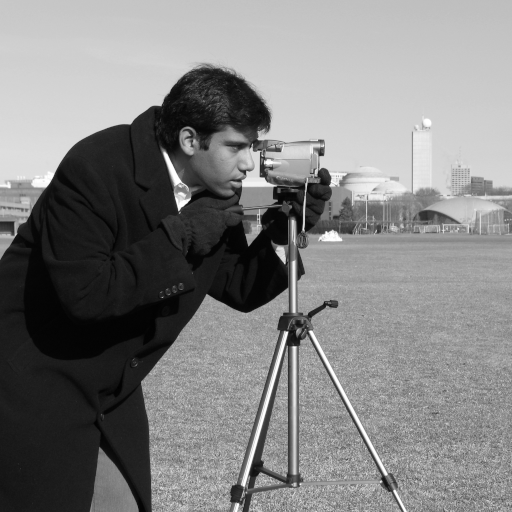

In [3]:
img = Image.fromarray(data.camera())

print("Original image size:", img.size)

display(img)

In [4]:
# ── Load image ────────────────────────────────────

### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [5]:
# Get the size of the image
width, height = img.size

# scaling factors
sx = 2
sy = 2

print("Original width:", width)
print("Original height:", height)


Original width: 512
Original height: 512


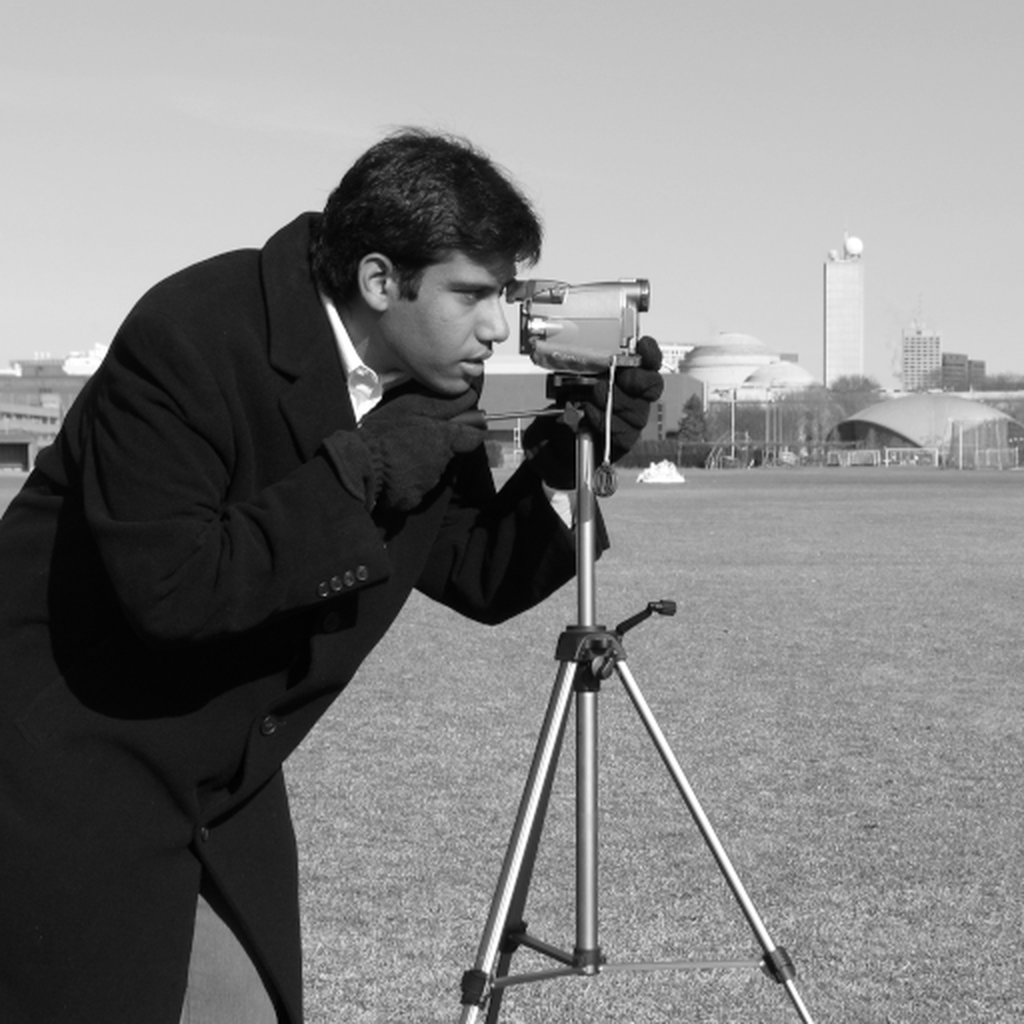

In [6]:
# ── 1. Increase size (scale ×2) ────────────────────
new_width = int(width * sx)
new_height = int(height * sy)

# Resize the image using PIL's built-in method
scaled_img = img.resize(
    (new_width, new_height),
    Image.Resampling.LANCZOS
)

display(scaled_img)


In [7]:

# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")

scaled_img.save("task1_1_scaled.jpg")

print("Original size:", img.size)
print("New size:", scaled_img.size)
print("Saved as: task1_1_scaled.jpg")


Original size: (512, 512)
New size: (1024, 1024)
Saved as: task1_1_scaled.jpg


 non-uniform scale (cx=2, cy=1) → stretch horizontally only

In [8]:
cx = 2
cy = 1

width, height = img.size

print("Original size:", img.size)

Original size: (512, 512)


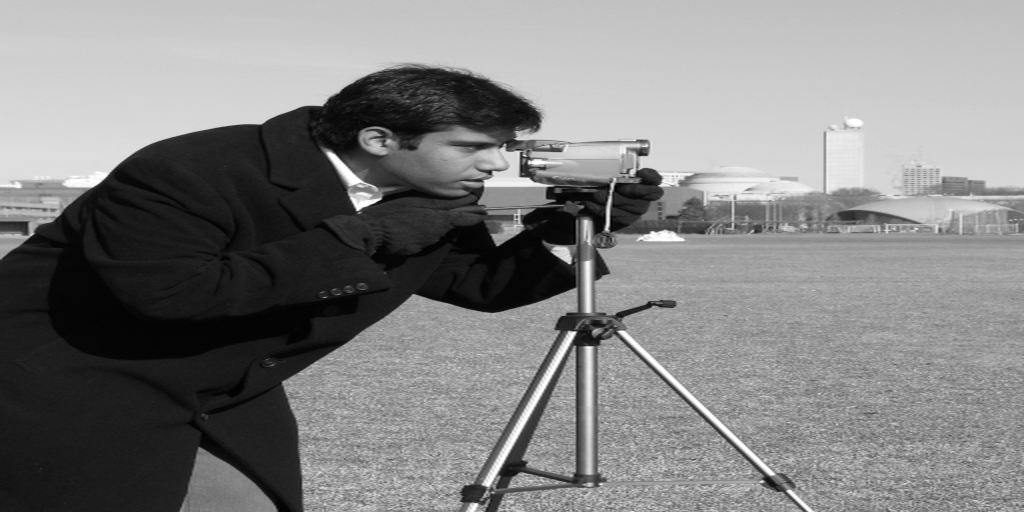

In [9]:
new_width = int(width * cx)
new_height = int(height * cy)

stretched_img = img.resize(
    (new_width, new_height),
    Image.Resampling.LANCZOS
)

display(stretched_img)

In [10]:
print("Original size:", img.size)
print("Non-uniform scaled size:", stretched_img.size)

Original size: (512, 512)
Non-uniform scaled size: (1024, 512)


### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

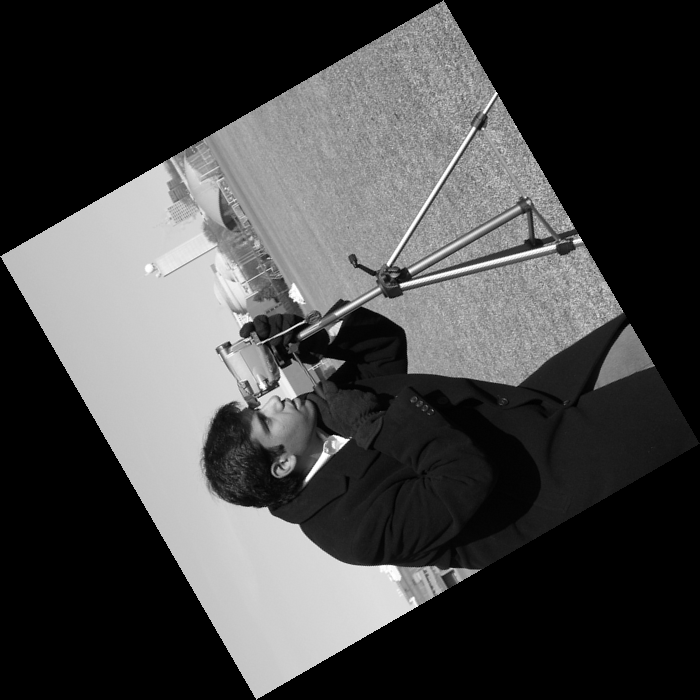

Original size: (512, 512)
Rotated size: (700, 700)
Saved as: task1_2_rotated.jpg


In [11]:
# ── 2. Rotate 120 degrees ──────────────────────────
rotated_img = img.rotate(
    120,
    expand=True,
    resample=Image.Resampling.BICUBIC
)

display(rotated_img)

# Save the scaled image and print the sizes (The new image name should be "task1_2_rotated.jpg")
rotated_img.save("task1_2_rotated.jpg")

print("Original size:", img.size)
print("Rotated size:", rotated_img.size)
print("Saved as: task1_2_rotated.jpg")

### 3. Shear

In [12]:
# -- c. Get the image dimensions ────────────────────
width, height = img.size

print("Image width:", width)
print("Image height:", height)

Image width: 512
Image height: 512


In [13]:
# -- d. define the shear matrix ──────────────────────────
shx = 0.5
shy = 0.0

print("X shear factor:", shx)
print("Y shear factor:", shy)

# Choose X-axis or Y-axis shear. The shear factor controls how much the image slants — start with 0.5 then experiment.
shear_matrix = [
    [1, shx],
    [0, 1]
]

print("Shear matrix:")
print(shear_matrix)

X shear factor: 0.5
Y shear factor: 0.0
Shear matrix:
[[1, 0.5], [0, 1]]


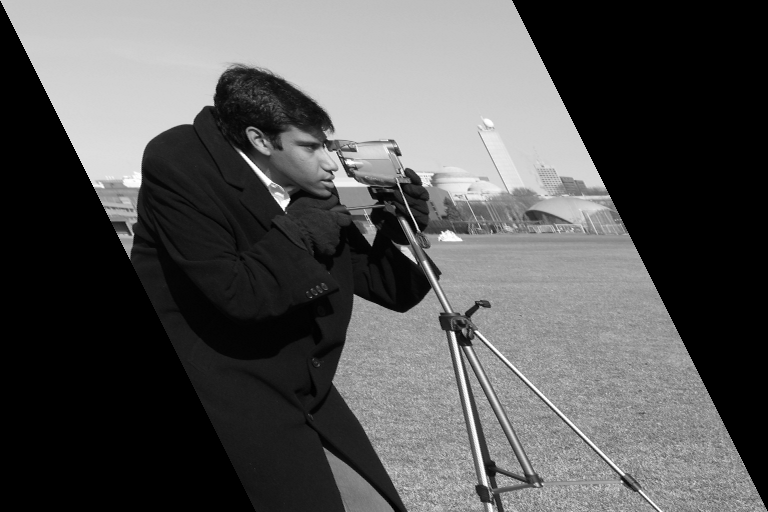

In [14]:
# -- e. Apply the shear transformation to the image ──────────────────────────

width, height = img.size

# Increase canvas width to avoid cropping
new_width = int(width + abs(shx) * height)
new_height = height

# PIL requires the inverse affine transformation
sheared_img = img.transform(
    (new_width, new_height),
    Image.Transform.AFFINE,
    (1, -shx, 0, 0, 1, 0),
    resample=Image.Resampling.BICUBIC
)

display(sheared_img)

In [15]:
# -- f. Save the sheared image(The new image name should be "task1_3_sheared.jpg")
sheared_img.save("task1_3_sheared.jpg")

print("Original size:", img.size)
print("Sheared size:", sheared_img.size)
print("Saved as: task1_3_sheared.jpg")

Original size: (512, 512)
Sheared size: (768, 512)
Saved as: task1_3_sheared.jpg


### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

Original image size: (512, 512)
X-shear = 0.1
Size: (563, 512)


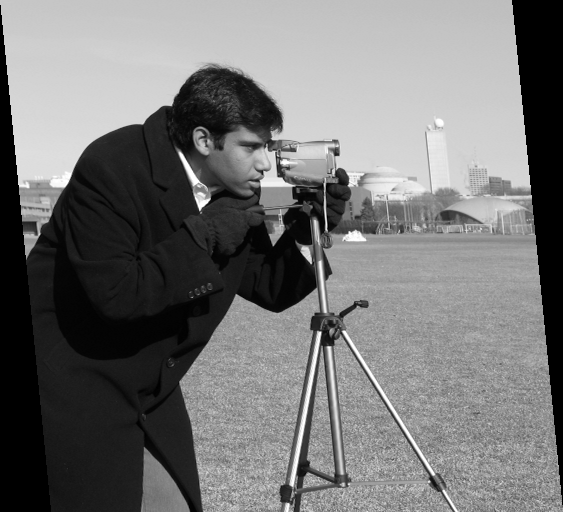


X-shear = 0.3
Size: (665, 512)


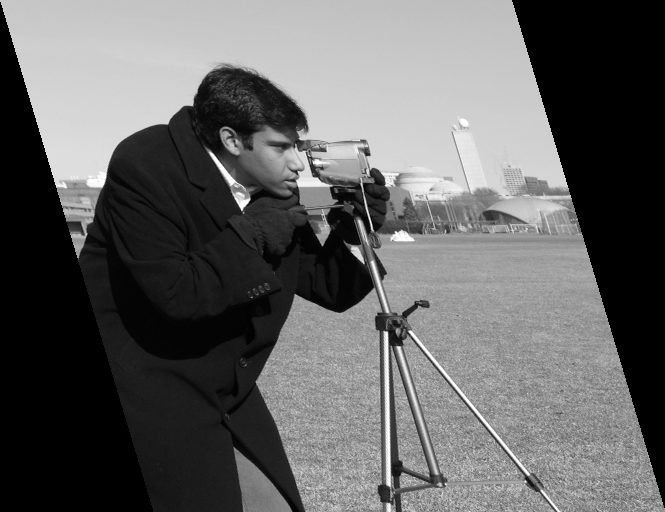


X-shear = 0.5
Size: (768, 512)


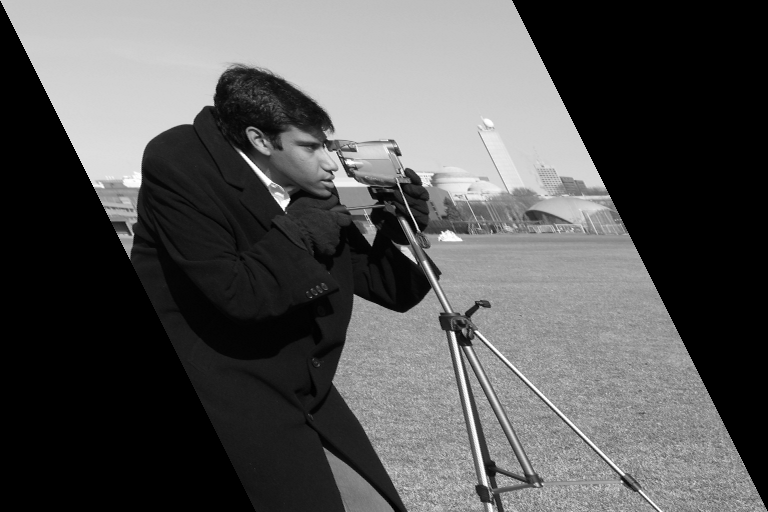


X-shear = 0.8
Size: (921, 512)


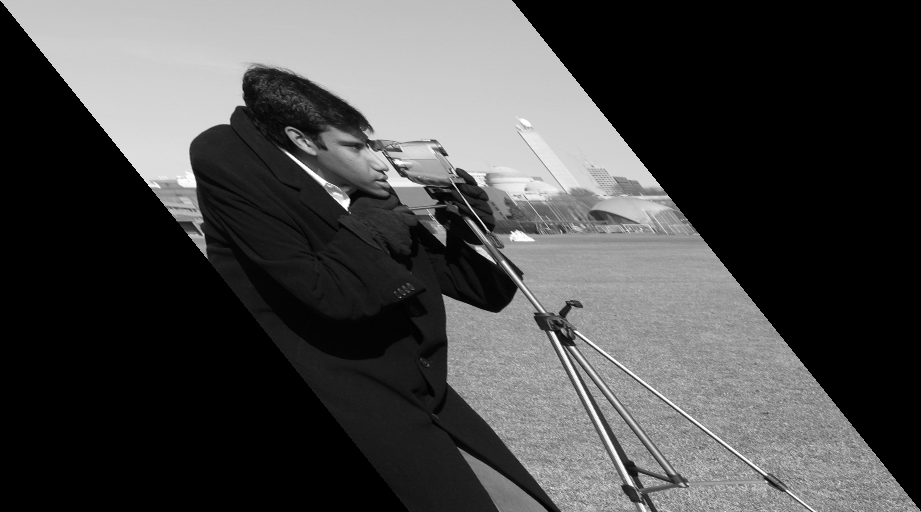


Y-shear = 0.5
Size: (512, 768)


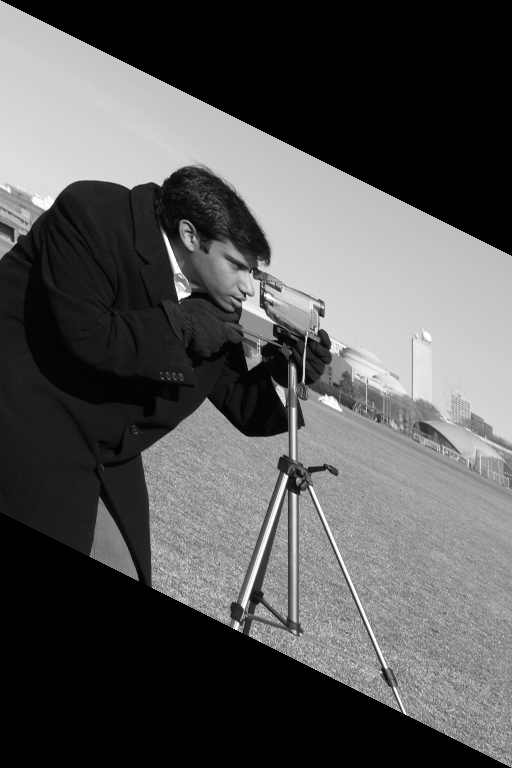


Combined X + Y shear
X shear factor: 0.3
Y shear factor: 0.2
Size: (665, 614)


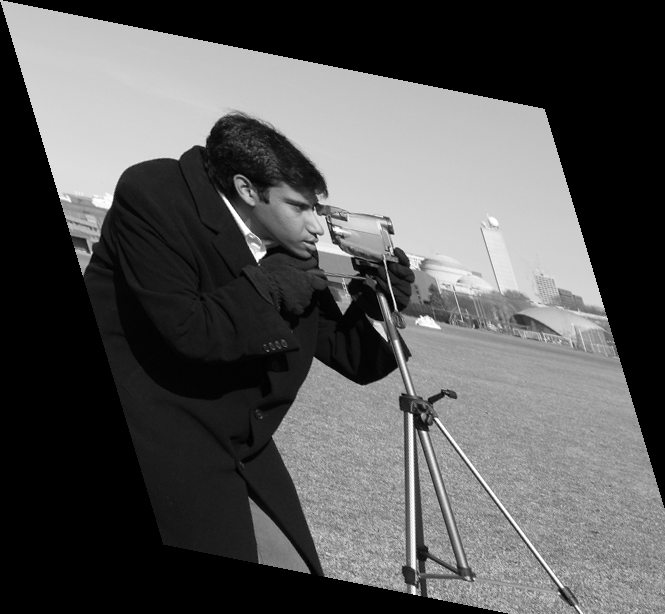

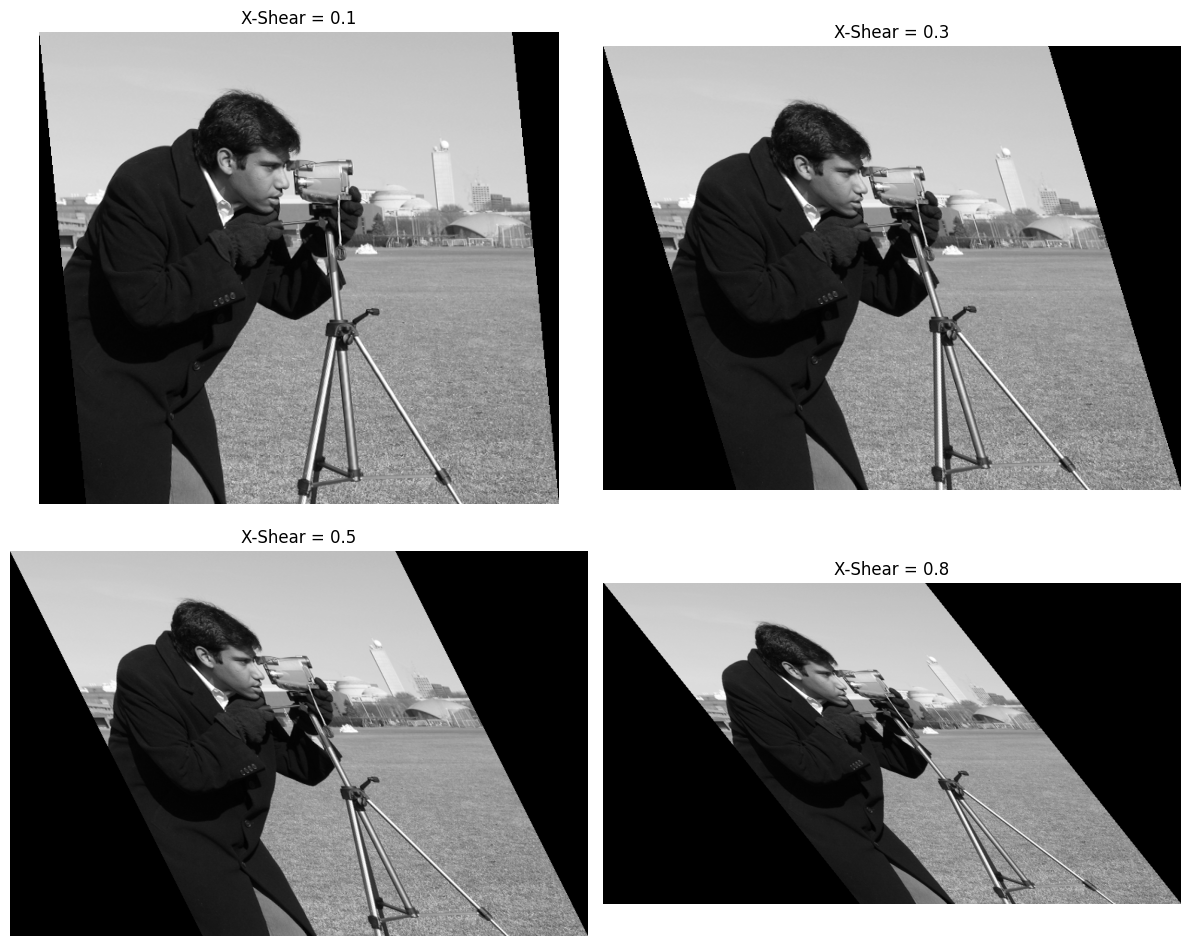

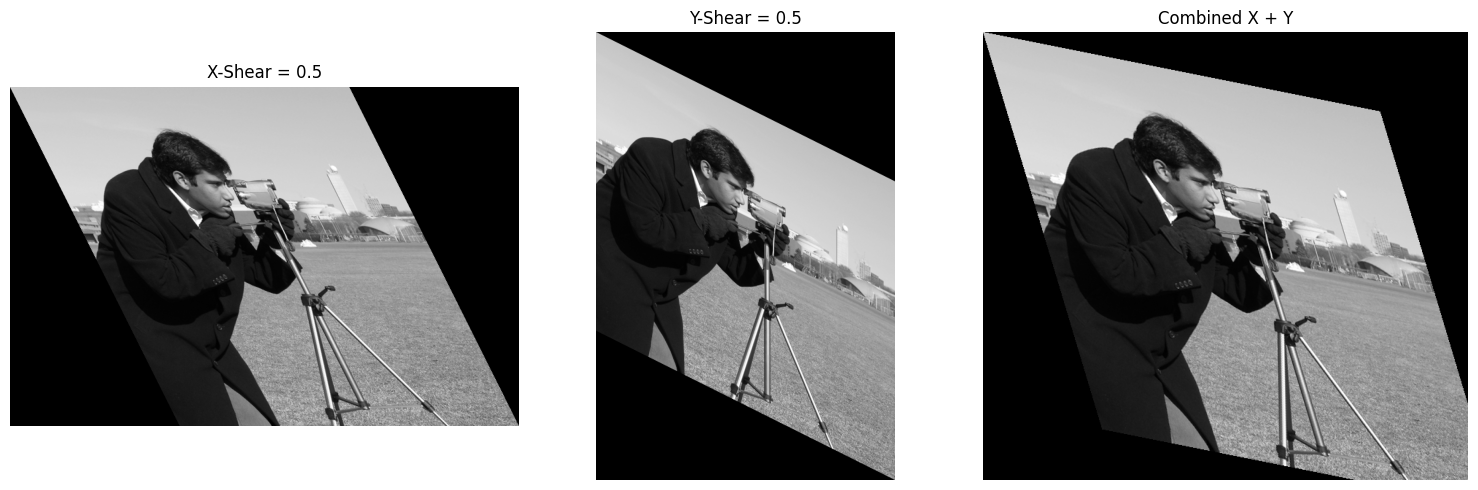

FINAL COMPARISON
Original image:        (512, 512)
X-shear 0.1:           (563, 512)
X-shear 0.3:           (665, 512)
X-shear 0.5:           (768, 512)
X-shear 0.8:           (921, 512)
Y-shear 0.5:           (512, 768)
Combined X+Y shear:    (665, 614)
All experiment images have been saved.


In [16]:
# ============================================================
# EXPERIMENT AND COMPARE - SHEAR TRANSFORMATIONS
# ============================================================

from PIL import Image
import matplotlib.pyplot as plt

# Get original image dimensions
width, height = img.size

print("Original image size:", img.size)
print("=" * 60)


# ============================================================
# 1. X-AXIS SHEAR - shx = 0.1
# ============================================================

shx = 0.1
shy = 0.0

new_width = int(width + abs(shx) * height)
new_height = height

shear_x_01 = img.transform(
    (new_width, new_height),
    Image.Transform.AFFINE,
    (1, -shx, 0, 0, 1, 0),
    resample=Image.Resampling.BICUBIC
)

print("X-shear = 0.1")
print("Size:", shear_x_01.size)

display(shear_x_01)

shear_x_01.save("experiment_x_shear_0.1.jpg")


# ============================================================
# 2. X-AXIS SHEAR - shx = 0.3
# ============================================================

shx = 0.3
shy = 0.0

new_width = int(width + abs(shx) * height)
new_height = height

shear_x_03 = img.transform(
    (new_width, new_height),
    Image.Transform.AFFINE,
    (1, -shx, 0, 0, 1, 0),
    resample=Image.Resampling.BICUBIC
)

print("\nX-shear = 0.3")
print("Size:", shear_x_03.size)

display(shear_x_03)

shear_x_03.save("experiment_x_shear_0.3.jpg")


# ============================================================
# 3. X-AXIS SHEAR - shx = 0.5
# ============================================================

shx = 0.5
shy = 0.0

new_width = int(width + abs(shx) * height)
new_height = height

shear_x_05 = img.transform(
    (new_width, new_height),
    Image.Transform.AFFINE,
    (1, -shx, 0, 0, 1, 0),
    resample=Image.Resampling.BICUBIC
)

print("\nX-shear = 0.5")
print("Size:", shear_x_05.size)

display(shear_x_05)

shear_x_05.save("experiment_x_shear_0.5.jpg")


# ============================================================
# 4. X-AXIS SHEAR - shx = 0.8
# ============================================================

shx = 0.8
shy = 0.0

new_width = int(width + abs(shx) * height)
new_height = height

shear_x_08 = img.transform(
    (new_width, new_height),
    Image.Transform.AFFINE,
    (1, -shx, 0, 0, 1, 0),
    resample=Image.Resampling.BICUBIC
)

print("\nX-shear = 0.8")
print("Size:", shear_x_08.size)

display(shear_x_08)

shear_x_08.save("experiment_x_shear_0.8.jpg")


# ============================================================
# 5. Y-AXIS SHEAR
# ============================================================

shx = 0.0
shy = 0.5

new_width = width
new_height = int(height + abs(shy) * width)

shear_y = img.transform(
    (new_width, new_height),
    Image.Transform.AFFINE,
    (1, 0, 0, -shy, 1, 0),
    resample=Image.Resampling.BICUBIC
)

print("\nY-shear = 0.5")
print("Size:", shear_y.size)

display(shear_y)

shear_y.save("experiment_y_shear_0.5.jpg")


# ============================================================
# 6. COMBINED X + Y SHEAR
# ============================================================

shx = 0.3
shy = 0.2

new_width = int(width + abs(shx) * height)
new_height = int(height + abs(shy) * width)

combined_shear = img.transform(
    (new_width, new_height),
    Image.Transform.AFFINE,
    (1, -shx, 0, -shy, 1, 0),
    resample=Image.Resampling.BICUBIC
)

print("\nCombined X + Y shear")
print("X shear factor:", shx)
print("Y shear factor:", shy)
print("Size:", combined_shear.size)

display(combined_shear)

combined_shear.save("experiment_combined_shear.jpg")


# ============================================================
# 7. COMPARE ALL X-SHEAR RESULTS
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

images = [
    (shear_x_01, "X-Shear = 0.1"),
    (shear_x_03, "X-Shear = 0.3"),
    (shear_x_05, "X-Shear = 0.5"),
    (shear_x_08, "X-Shear = 0.8")
]

for ax, (image, title) in zip(axes.ravel(), images):
    ax.imshow(image, cmap="gray")
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()


# ============================================================
# 8. COMPARE X-SHEAR, Y-SHEAR AND COMBINED SHEAR
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(shear_x_05, cmap="gray")
axes[0].set_title("X-Shear = 0.5")
axes[0].axis("off")

axes[1].imshow(shear_y, cmap="gray")
axes[1].set_title("Y-Shear = 0.5")
axes[1].axis("off")

axes[2].imshow(combined_shear, cmap="gray")
axes[2].set_title("Combined X + Y")
axes[2].axis("off")

plt.tight_layout()
plt.show()


# ============================================================
# 9. PRINT FINAL COMPARISON
# ============================================================

print("=" * 60)
print("FINAL COMPARISON")
print("=" * 60)

print("Original image:       ", img.size)
print("X-shear 0.1:          ", shear_x_01.size)
print("X-shear 0.3:          ", shear_x_03.size)
print("X-shear 0.5:          ", shear_x_05.size)
print("X-shear 0.8:          ", shear_x_08.size)
print("Y-shear 0.5:          ", shear_y.size)
print("Combined X+Y shear:   ", combined_shear.size)

print("=" * 60)
print("All experiment images have been saved.")



# Intensity Transformations
Negative · Log · Power Law (Gamma)

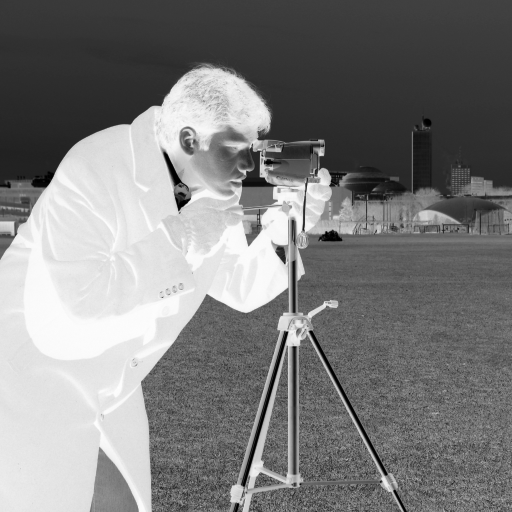

In [21]:

# ── 1. Negative ────────────────────────────────────
# Method 1: NumPy array manipulation
arr = np.array(img)

negative_arr = 255 - arr

negative_img = Image.fromarray( negative_arr.astype(np.uint8))

display(negative_img)

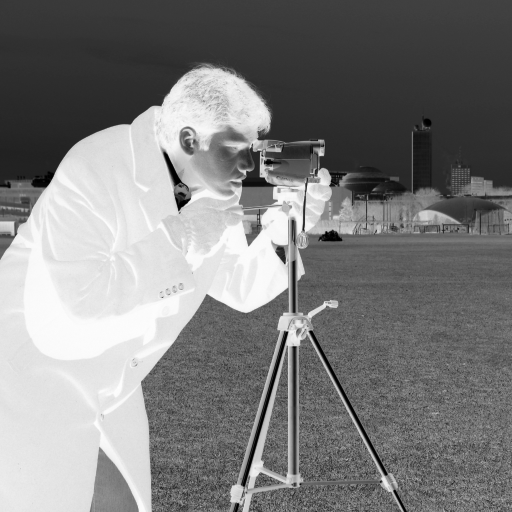

In [22]:
# Method 2: PIL's ImageOps
negative_pil = ImageOps.invert(img)

display(negative_pil)

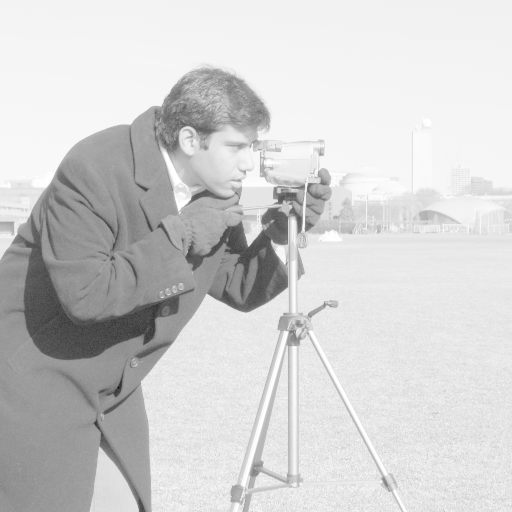

Saved as: log_transformed.jpg


In [19]:
# ── 2. Log transformation ──────────────────────────
arr = np.array(img).astype(np.float32)

# s = c · log(1 + r) --> We need to find c.
c = 255 / np.log(256)
# We want the maximum output value (s) to be 255 when the maximum input value (r) is 255:
# 255 = c · log(1 + 255)
# c = 255 / log(1 + 255)



# Apply the log transformation to each pixel
log_transformed_arr = c * np.log1p(arr)
log_transformed_arr = np.clip(
    log_transformed_arr,
    0,
    255
)

# Convert to uint8 image
log_img = Image.fromarray(
    log_transformed_arr.astype(np.uint8)
)

display(log_img)
log_img.save("log_transformed.jpg")

print("Saved as: log_transformed.jpg")

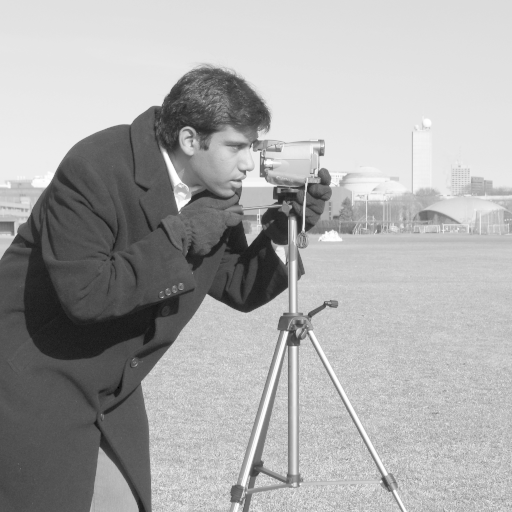

Gamma: 0.5
Saved as: gamma_transformed.jpg


In [20]:

# ── 3. Power-law / Gamma correction ───────────────
# ── 3. Power-law / Gamma correction ────────────────

arr = np.array(img).astype(np.float32)

# Normalize pixels from [0, 255] to [0, 1]
normalized = arr / 255.0

# Gamma value
gamma = 0.5

# Apply power-law transformation
gamma_transformed = np.power(normalized, gamma)

# Convert back to [0, 255]
gamma_transformed = gamma_transformed * 255

# Make sure values are valid
gamma_transformed = np.clip(
    gamma_transformed,
    0,
    255
)

# Convert to image
gamma_img = Image.fromarray(
    gamma_transformed.astype(np.uint8)
)

display(gamma_img)

# Save
gamma_img.save("gamma_transformed.jpg")

print("Gamma:", gamma)
print("Saved as: gamma_transformed.jpg")
